# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Muhammad Zaki Nanda Wahyudi | 5054251007 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [76]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from IPython.display import display

In [77]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("Breast_Cancer_Wisconsin.csv")

print(f"Jumlah Baris: {df.shape[0]}")
print(f"Jumlah Kolom: {df.shape[1]}")

print("\nTipe Data tiap Feature")
print(df.dtypes)

display(df.describe())

print("Jumlah Missing Value:")
miss = df.isnull().sum()
miss_perc = df.isnull().mean() * 100
miss_df = pd.DataFrame(
    {"Jumlah Missing Value": miss, "Persentase": miss_perc}
)
miss_df

Jumlah Baris: 569
Jumlah Kolom: 33

Tipe Data tiap Feature
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           floa

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Jumlah Missing Value:


,Jumlah Missing Value,Persentase
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_7892\181455559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='diagnosis', palette='viridis')


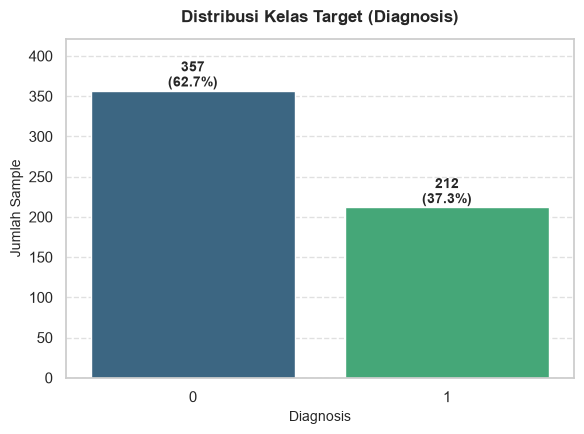

Jumlah Sampel per Kelas:
diagnosis
0    357
1    212
Name: count, dtype: int64

Persentase Kelas (%):
diagnosis
0    62.74
1    37.26
Name: proportion, dtype: float64
Dataset ini mengalami ketidakseimbangan ringan dengan rasio sekitar 63% : 37%


In [102]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
# Visualisasi Distribusi Kelas Target
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(data=df, x='diagnosis', palette='viridis')

# Menambahkan label jumlah dan persentase di atas setiap bar
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(f'{count}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Distribusi Kelas Target (Diagnosis)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Diagnosis', fontsize=10)
plt.ylabel('Jumlah Sample', fontsize=10)
plt.ylim(0, max(df['diagnosis'].value_counts()) * 1.18)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Cek angka rinci
print("Jumlah Sampel per Kelas:")
print(df['diagnosis'].value_counts())
print("\nPersentase Kelas (%):")
print((df['diagnosis'].value_counts(normalize=True) * 100).round(2))

print("Dataset ini mengalami ketidakseimbangan ringan dengan rasio sekitar 63% : 37%")

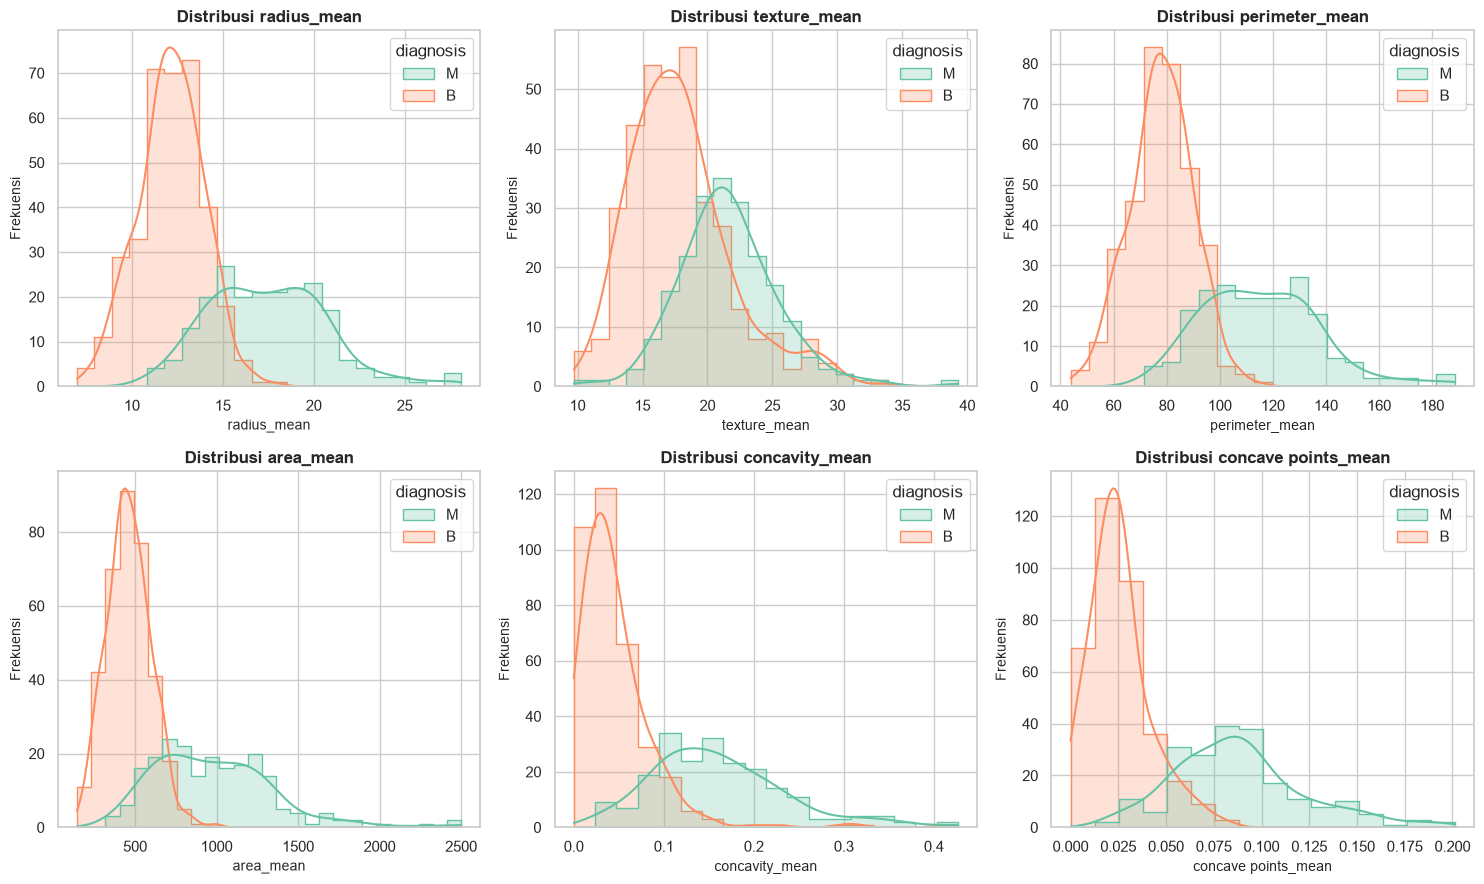

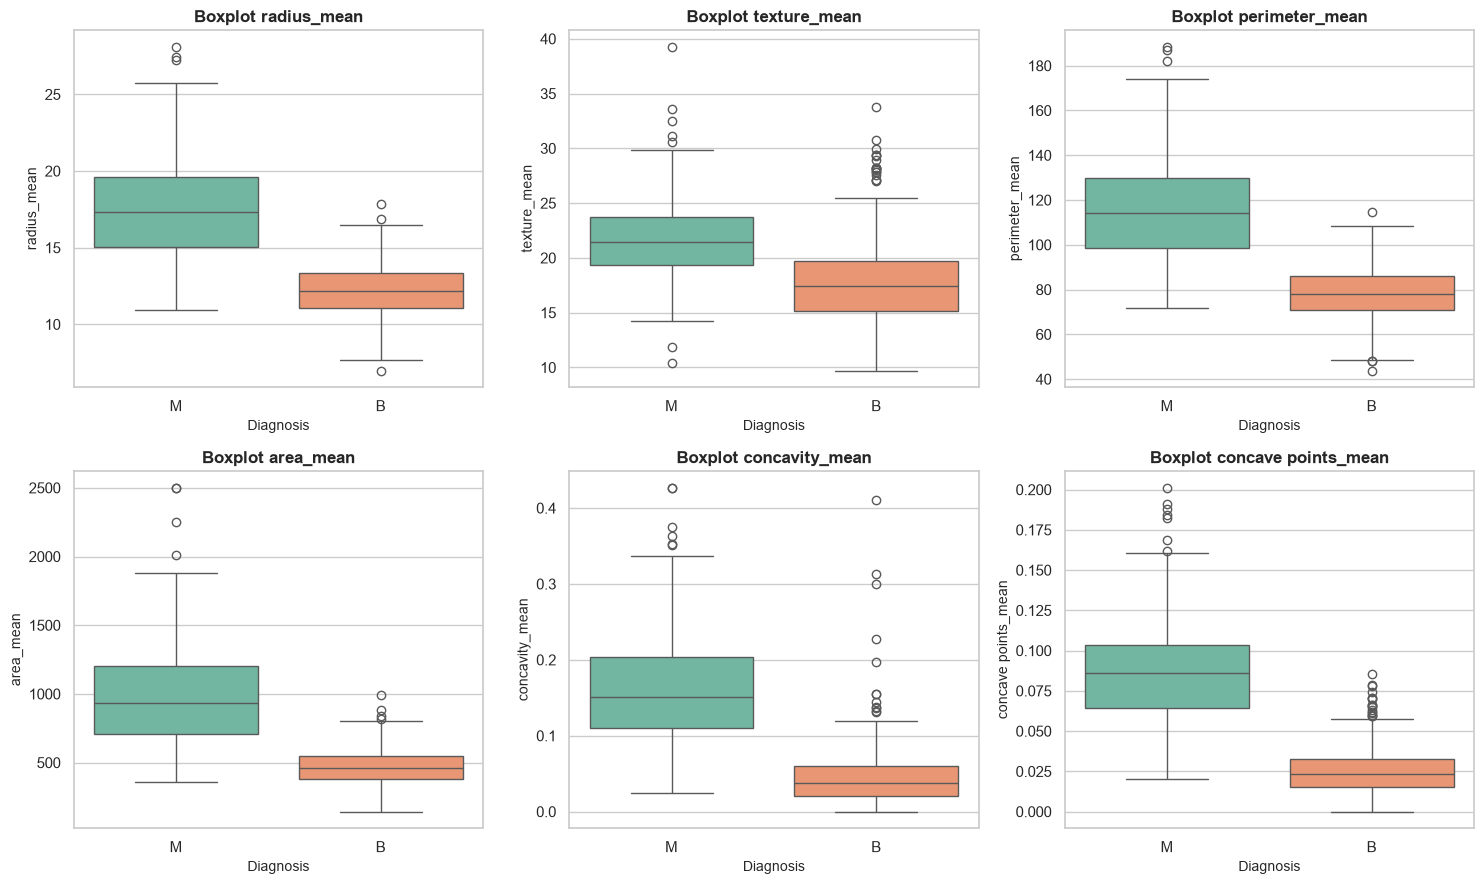

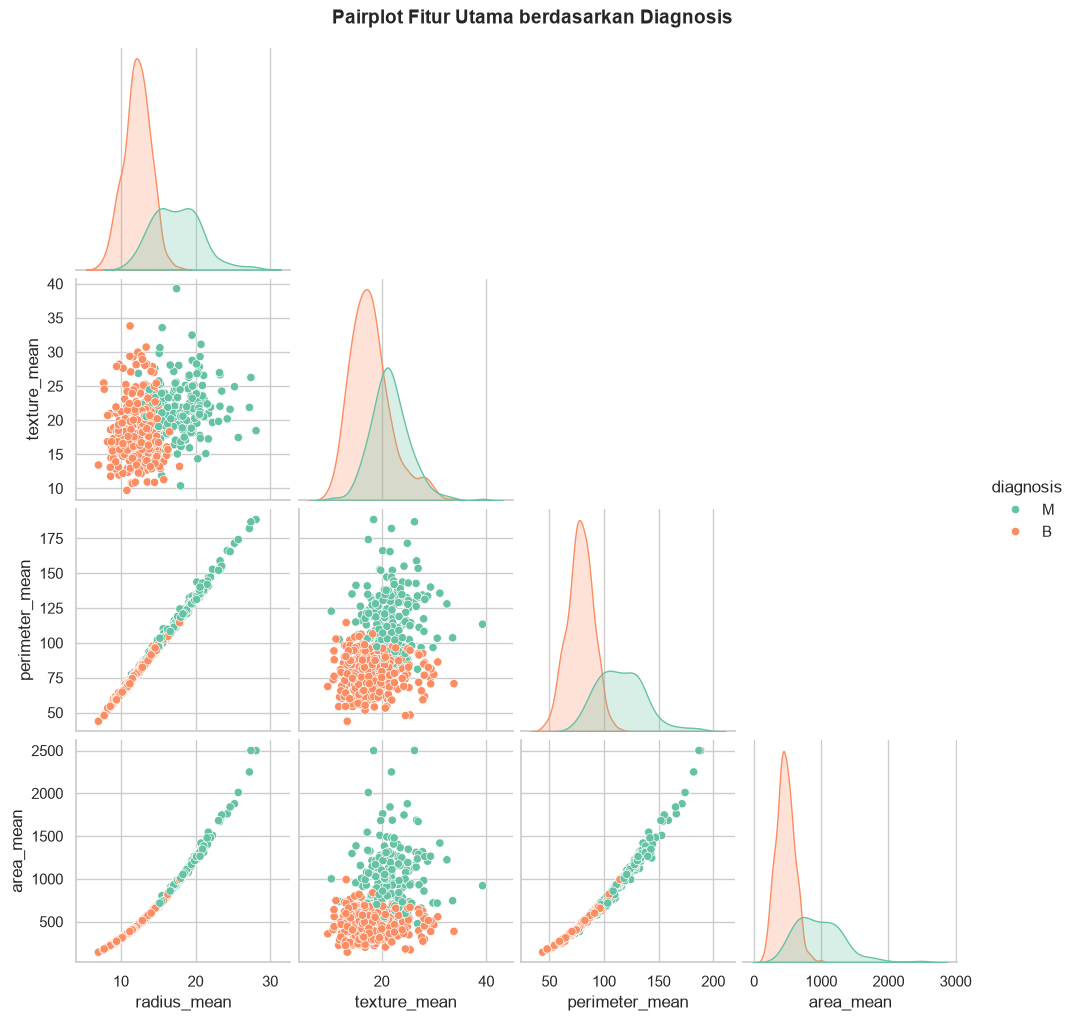

In [79]:
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])
if 'id' in df.columns:
    df = df.drop(columns=['id'])

features_mean = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 
    'area_mean', 'concavity_mean', 'concave points_mean'
]

sns.set_theme(style="whitegrid")

# 1. Histogram / KDE Distribution Plot
plt.figure(figsize=(15, 9))
for i, col in enumerate(features_mean, 1):
    plt.subplot(2, 3, i)
    sns.histplot(
        data=df, x=col, hue='diagnosis', kde=True, 
        palette='Set2', element='step', common_norm=False
    )
    plt.title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frekuensi', fontsize=10)

plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(15, 9))
for i, col in enumerate(features_mean, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        data=df, 
        x='diagnosis', 
        y=col, 
        hue='diagnosis',   
        palette='Set2', 
        legend=False       
    )
    plt.title(f'Boxplot {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Diagnosis', fontsize=10)
    plt.ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

# 3. Pairplot (Hubungan Antar Pasangan Fitur Utama)
pair_cols = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']
g = sns.pairplot(df[pair_cols], hue='diagnosis', palette='Set2', corner=True, diag_kind='kde')
g.fig.suptitle('Pairplot Fitur Utama berdasarkan Diagnosis', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

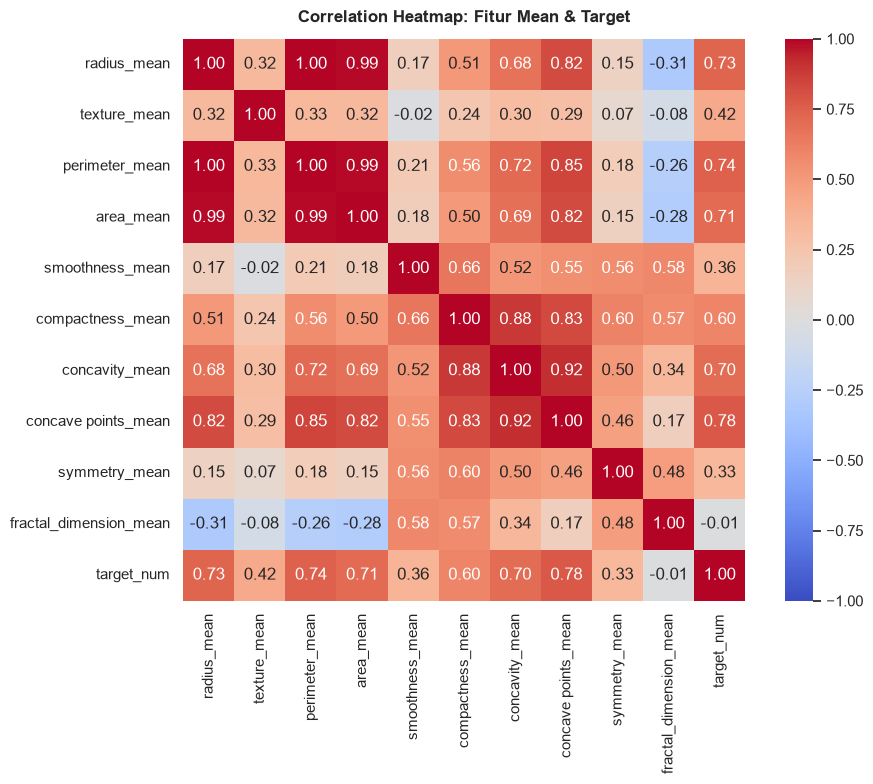

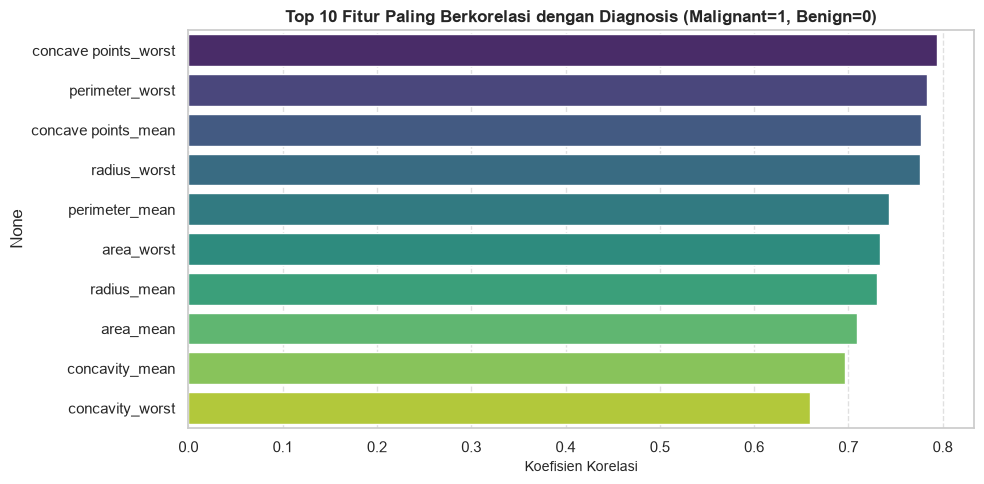

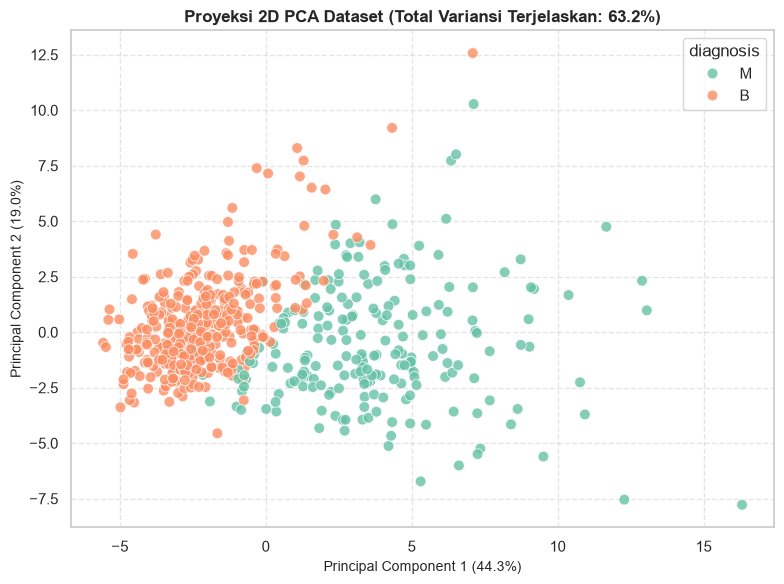

In [80]:
df_eda = df.copy()
df_eda['target_num'] = df_eda['diagnosis'].map({'M': 1, 'B': 0})

#  Correlation Heatmap Fitur Mean & Target

mean_cols = [c for c in df_eda.columns if 'mean' in c] + ['target_num']
corr_mean = df_eda[mean_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mean, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap: Fitur Mean & Target", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


# Top 10 Fitur Paling Berkorelasi dengan Target (Diagnosis)

numeric_df = df_eda.select_dtypes(include=[np.number])
target_corr = numeric_df.corr()['target_num'].drop('target_num').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=target_corr.head(10).values, y=target_corr.head(10).index, palette='viridis', hue=target_corr.head(10).index, legend=False)
plt.title("Top 10 Fitur Paling Berkorelasi dengan Diagnosis (Malignant=1, Benign=0)", fontsize=12, fontweight='bold')
plt.xlabel("Koefisien Korelasi", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Visualisasi Proyeksi 2D Dataset Menggunakan PCA

X_all = df.drop(columns=['diagnosis'])
X_scaled_pca = StandardScaler().fit_transform(X_all.select_dtypes(include=[np.number]))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis'] = df['diagnosis'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='diagnosis', palette='Set2', alpha=0.8, s=60)
var_exp = pca.explained_variance_ratio_ * 100
plt.title(f"Proyeksi 2D PCA Dataset (Total Variansi Terjelaskan: {var_exp.sum():.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel(f"Principal Component 1 ({var_exp[0]:.1f}%)", fontsize=10)
plt.ylabel(f"Principal Component 2 ({var_exp[1]:.1f}%)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [81]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])
    print("\nKolom 'Unnamed: 32' berhasil dihapus.")

if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("Kolom 'id' berhasil dihapus.")

total_missing = df.isnull().sum().sum()
print(f"\nSisa total missing value pada dataset: {total_missing}")


Sisa total missing value pada dataset: 0


In [82]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
print("Kolom kategorikal yang ditemukan:", categorical_cols)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("\nTipe data 'diagnosis' setelah encoding:", df['diagnosis'].dtype)
print("\nDistribusi kelas target (1 = Malignant, 0 = Benign):")
print(df['diagnosis'].value_counts())

Kolom kategorikal yang ditemukan: ['diagnosis']

Tipe data 'diagnosis' setelah encoding: int64

Distribusi kelas target (1 = Malignant, 0 = Benign):
diagnosis
0    357
1    212
Name: count, dtype: int64


In [83]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah sampel Train set (X_train): {X_train.shape[0]} baris, {X_train.shape[1]} fitur")
print(f"Jumlah sampel Test set  (X_test) : {X_test.shape[0]} baris, {X_test.shape[1]} fitur")

print("\nProporsi kelas pada Training Set:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nProporsi kelas pada Testing Set:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Jumlah sampel Train set (X_train): 455 baris, 30 fitur
Jumlah sampel Test set  (X_test) : 114 baris, 30 fitur

Proporsi kelas pada Training Set:
diagnosis
0    62.64
1    37.36
Name: proportion, dtype: float64

Proporsi kelas pada Testing Set:
diagnosis
0    63.16
1    36.84
Name: proportion, dtype: float64


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [84]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling selesai dilakukan!")
print(f"Rata-rata fitur X_train_scaled : {X_train_scaled.mean().mean():.4f} (~0)")
print(f"Standar deviasi X_train_scaled : {X_train_scaled.std().mean():.4f} (~1)")

Scaling selesai dilakukan!
Rata-rata fitur X_train_scaled : 0.0000 (~0)
Standar deviasi X_train_scaled : 1.0011 (~1)


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [85]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).

svm_linear = SVC(kernel='linear', random_state=42)

svm_linear.fit(X_train_scaled, y_train)

print("Pelatihan model SVC (Kernel Linear) selesai!")

Pelatihan model SVC (Kernel Linear) selesai!


In [86]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_linear = svm_linear.predict(X_test_scaled)
y_proba_linear = svm_linear.decision_function(X_test_scaled)

print("Prediksi berhasil disimpan!")
print(f"Jumlah sampel test set yang diprediksi : {len(y_pred_linear)}")
print(f"Prediksi kelas Malignant (1) - Linear  : {sum(y_pred_linear)}")

Prediksi berhasil disimpan!
Jumlah sampel test set yang diprediksi : 114
Prediksi kelas Malignant (1) - Linear  : 38


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [87]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.

svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)

svm_rbf.fit(X_train_scaled, y_train)

print("Pelatihan model SVC (Kernel RBF) selesai!")

Pelatihan model SVC (Kernel RBF) selesai!


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_proba_rbf = svm_rbf.decision_function(X_test_scaled)

print("Prediksi pada test set (Kernel RBF) berhasil disimpan!")
print(f"Total sampel yang diprediksi : {len(y_pred_rbf)}")
print(f"Jumlah prediksi Benign (0)   : {(y_pred_rbf == 0).sum()}")
print(f"Jumlah prediksi Malignant (1): {(y_pred_rbf == 1).sum()}")

Prediksi pada test set (Kernel RBF) berhasil disimpan!
Total sampel yang diprediksi : 114
Jumlah prediksi Benign (0)   : 75
Jumlah prediksi Malignant (1): 39


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [99]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.

from sklearn.svm import SVC

# Daftar variasi nilai C yang akan diuji
c_values = [0.01, 0.1, 1, 10, 100]

# Dictionary untuk menyimpan model yang telah dilatih
models_rbf = {}

# Melatih model SVC (kernel RBF) untuk setiap nilai C
for c in c_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    models_rbf[c] = model

print("Pelatihan model SVC (kernel RBF) dengan variasi nilai C selesai dilakukan.")

Pelatihan model SVC (kernel RBF) dengan variasi nilai C selesai dilakukan.


In [ ]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

train_accuracies = []
test_accuracies = []

for c in c_values:
    model = models_rbf[c]
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

print("Akurasi Training:", train_accuracies)
print("Akurasi Testing :", test_accuracies)

Akurasi Training: [0.6263736263736264, 0.9538461538461539, 0.9868131868131869, 0.989010989010989, 1.0]
Akurasi Testing : [0.631578947368421, 0.9473684210526315, 0.9736842105263158, 0.9736842105263158, 0.9649122807017544]


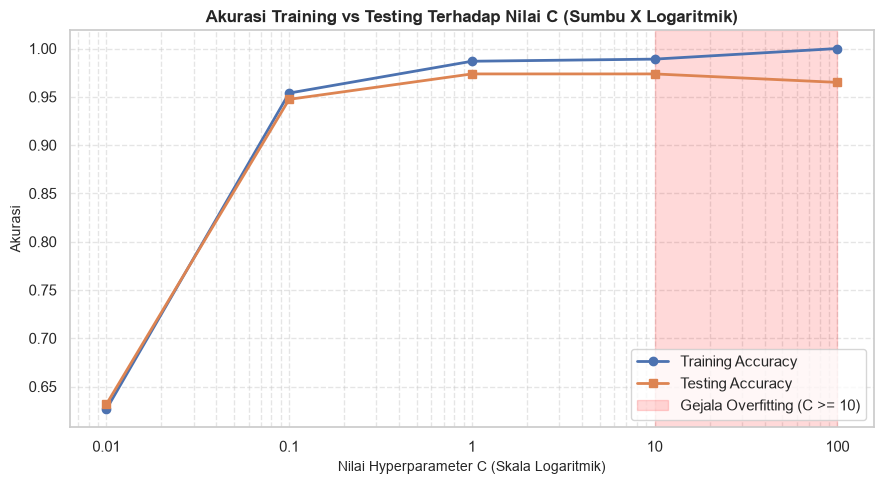

In [103]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(9, 5))
plt.semilogx(c_values, train_accuracies, marker='o', label='Training Accuracy', linewidth=2)
plt.semilogx(c_values, test_accuracies, marker='s', label='Testing Accuracy', linewidth=2)

plt.axvspan(10, 100, color='red', alpha=0.15, label='Gejala Overfitting (C >= 10)')

plt.title('Akurasi Training vs Testing Terhadap Nilai C (Sumbu X Logaritmik)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Hyperparameter C (Skala Logaritmik)', fontsize=10)
plt.ylabel('Akurasi', fontsize=10)
plt.xticks(c_values, labels=[str(c) for c in c_values])
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [104]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

metrics_linear = {
    'Kernel': 'Linear',
    'Accuracy': accuracy_score(y_test, y_pred_linear),
    'Precision': precision_score(y_test, y_pred_linear),
    'Recall': recall_score(y_test, y_pred_linear),
    'F1-Score': f1_score(y_test, y_pred_linear)
}

metrics_rbf = {
    'Kernel': 'RBF (C=1.0)',
    'Accuracy': accuracy_score(y_test, y_pred_rbf),
    'Precision': precision_score(y_test, y_pred_rbf),
    'Recall': recall_score(y_test, y_pred_rbf),
    'F1-Score': f1_score(y_test, y_pred_rbf)
}

df_comparison = pd.DataFrame([metrics_linear, metrics_rbf])

print(df_comparison.to_string(index=False))

     Kernel  Accuracy  Precision   Recall  F1-Score
     Linear  0.964912        1.0 0.904762  0.950000
RBF (C=1.0)  0.973684        1.0 0.928571  0.962963


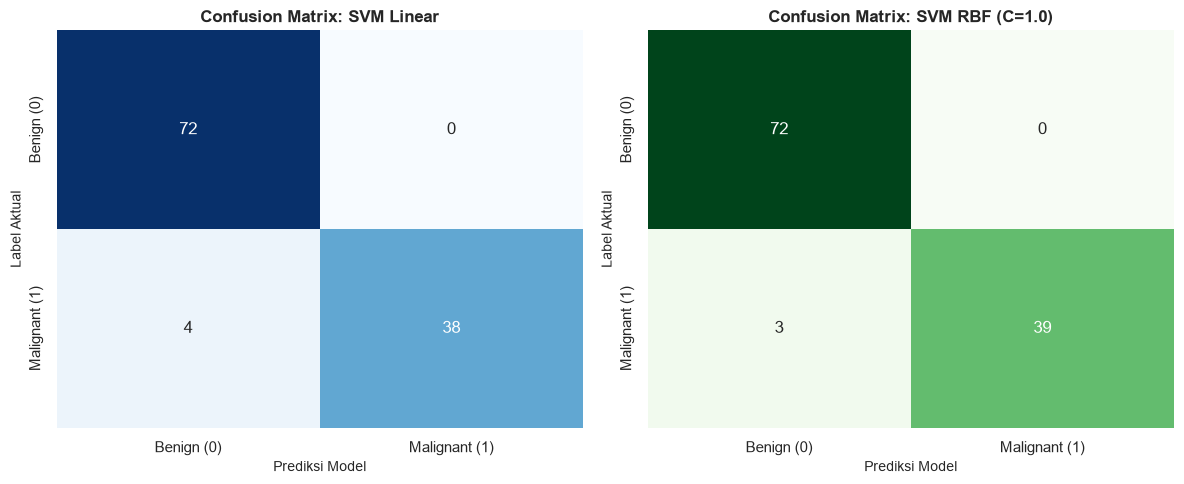

In [105]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[0].set_title('Confusion Matrix: SVM Linear', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model', fontsize=10)
axes[0].set_ylabel('Label Aktual', fontsize=10)

sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[1].set_title('Confusion Matrix: SVM RBF (C=1.0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model', fontsize=10)
axes[1].set_ylabel('Label Aktual', fontsize=10)

plt.tight_layout()
plt.show()

In [106]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.

sv_linear_per_class = svm_linear.n_support_
sv_rbf_per_class = svm_rbf.n_support_

total_sv_linear = sum(sv_linear_per_class)
total_sv_rbf = sum(sv_rbf_per_class)

df_sv_comparison = pd.DataFrame({
    'Model Kernel': ['Linear', 'RBF (C=1.0)'],
    'Support Vectors (Class 0 - Benign)': [sv_linear_per_class[0], sv_rbf_per_class[0]],
    'Support Vectors (Class 1 - Malignant)': [sv_linear_per_class[1], sv_rbf_per_class[1]],
    'Total Support Vectors': [total_sv_linear, total_sv_rbf],
    'Persentase dari Train Data (%):': [
        f"{(total_sv_linear / len(X_train_scaled)) * 100:.2f}%",
        f"{(total_sv_rbf / len(X_train_scaled)) * 100:.2f}%"
    ]
})

print("=== PERBANDINGAN JUMLAH SUPPORT VECTORS ===")
print(df_sv_comparison.to_string(index=False))

=== PERBANDINGAN JUMLAH SUPPORT VECTORS ===
Model Kernel  Support Vectors (Class 0 - Benign)  Support Vectors (Class 1 - Malignant)  Total Support Vectors Persentase dari Train Data (%):
      Linear                                  19                                     19                     38                           8.35%
 RBF (C=1.0)                                  50                                     57                    107                          23.52%


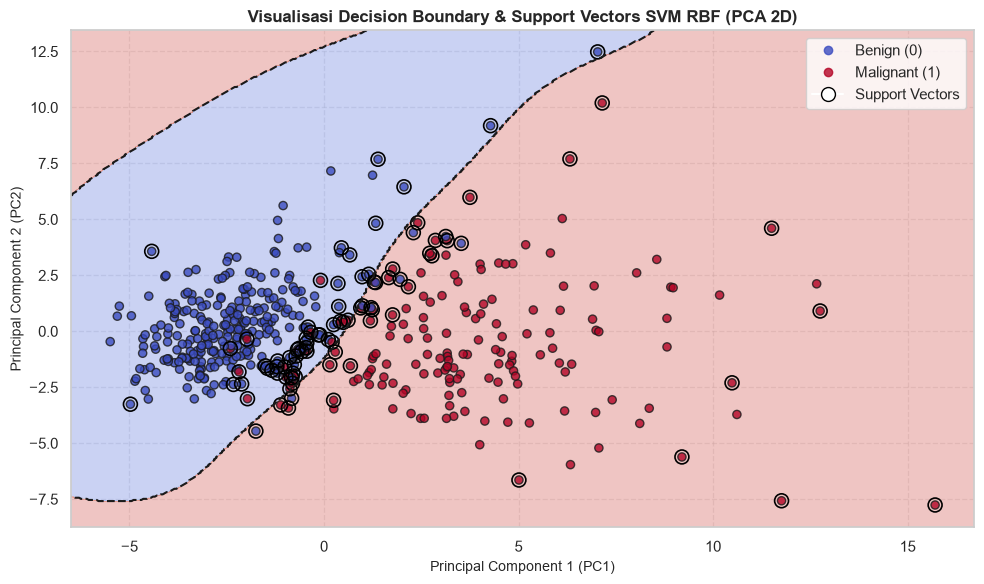

In [107]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

svm_rbf_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf_2d.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

plt.contour(xx, yy, Z, colors='k', levels=[0.5], linewidths=1.5, linestyles='--')

scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
                      cmap=plt.cm.coolwarm, edgecolors='k', s=35, alpha=0.8)

sv = svm_rbf_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', 
            edgecolors='black', linewidths=1.2, label='Support Vectors')

plt.title('Visualisasi Decision Boundary & Support Vectors SVM RBF (PCA 2D)', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=10)
plt.ylabel('Principal Component 2 (PC2)', fontsize=10)

handles, _ = scatter.legend_elements()
plt.legend(handles=handles + [plt.Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markersize=10)],
           labels=['Benign (0)', 'Malignant (1)', 'Support Vectors'], loc='upper right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

# 5. Analisis

## 5.1 Perbandingan Performa SVM Kernel Linear vs. Kernel RBF

Berikut adalah tabel perbandingan hasil evaluasi kedua kernel pada test set:

| Model Kernel | Accuracy | Precision | Recall | F1-Score | False Negative (FN) |
| --- | --- | --- | --- | --- | --- |
| **SVM Linear ($C=1.0$)** | 96.49% | 100.00% | 90.48% | 95.00% | 4 |
| **SVM RBF ($C=1.0$)** | **97.37%** | **100.00%** | **92.86%** | **96.30%** | **3** |

* **Performa Metrik:**
Kedua kernel menghasilkan performa yang tinggi (>96% akurasi). Namun, **Kernel RBF ($C=1.0$)** mengungguli Kernel Linear di seluruh metrik utama, yaitu Akurasi (**97.37%** vs 96.49%), Recall (**92.86%** vs 90.48%), dan F1-Score (**96.30%** vs 95.00%).


* **Perspektif Domain Medis:**
Kedua model mencapai *Precision* **100.00%** (0 *False Positive*), artinya tidak ada pasien sehat (*Benign*) yang salah terprediksi menderita tumor ganas (*Malignant*). Namun, Kernel RBF berhasil menekan angka *False Negative* dari 4 pasien menjadi 3 pasien. Dalam diagnosis kanker, penurunan *False Negative* sangat krusial untuk meminimalkan risiko pasien kanker terlewat dari penanganan medis.


* **Keterkaitan dengan Sebaran Data (EDA & Visualisasi PCA):**
Berdasarkan peta sebaran data 2D (PCA), sebaran fitur antara kelas *Benign* (0) dan *Malignant* (1) sebagian besar terpisah secara jelas di area pusat. Namun, pada wilayah perbatasan antar kelas, terdapat area yang *overlapping* (tumpang tindih) secara non-linier.


* Kernel Linear dibatasi oleh garis/hiperbidang lurus, sehingga terpaksa memotong area pemisah secara kaku dan menyebabkannya gagal mengklasifikasikan beberapa sampel di batas wilayah.


* Kernel RBF memproyeksikan data ke dimensi lebih tinggi (*kernel trick*), membantunya membentuk batas keputusan melengkung (*curved boundary*) yang lebih fleksibel mengelilingi lekukan pola *overlapping* tersebut.





---

## 5.2 Temuan Eksperimen Regularisasi Hyperparameter $C$

Hasil eksperimen pengaruh variasi nilai $C$ pada SVM Kernel RBF ($gamma=\text{'scale'}$) tercantum dalam tabel berikut:

| Nilai $C$ | Train Accuracy | Test Accuracy | Status Performa Model |
| --- | --- | --- | --- |
| **0.01** | 62.64% | 63.16% | **Underfitting** (Regularisasi terlalu kuat)

 |
| **0.10** | 95.38% | 94.74% | Performa membaik

 |
| **1.00** | **98.68%** | **97.37%** | **Sweet Spot / Optimal**<br> |
| **10.00** | 98.90% | 97.37% | **Awal Gejala Overfitting** (Akurasi test stagnan)

 |
| **100.00** | 100.00% | 96.49% | **Overfitting Jelas** (Akurasi test turun)

 |

* **Karakteristik Grafik Akurasi (Train vs Test):**
* **Underfitting ($C = 0.01$):** Penalti misklasifikasi sangat kecil. Model memprediksi seluruh sampel ke kelas mayoritas, menghasilkan akurasi *train* dan *test* yang sama-sama rendah ($\approx 63\%$).


* **Titik Optimal ($C = 1.0$):** Menghasilkan keseimbangan terbaik antara *bias* dan *variance* dengan Akurasi *Test* tertinggi di **97.37%**.


* **Gejala Overfitting ($C \ge 10.0$):**
* Pada **$C = 10.0$**, akurasi *train* naik menjadi 98.90%, namun akurasi *test* mulai **stagnan** di angka 97.37%. Ini menjadi indikator awal munculnya *overfitting*.


* Pada **$C = 100.0$**, akurasi *train* terus meningkat hingga **100.00%** (model menghafal data latihan sempurna), tetapi akurasi *test* justru **menurun** menjadi **96.49%**.






* **Penyebab:**
Nilai $C$ yang terlalu tinggi memperkecil *margin* pemisah dan memberikan penalti sangat berat pada kesalahan klasifikasi data *training*. Akibatnya, batas keputusan menjadi sangat sensitif terhadap *noise* dan titik data individual, sehingga menurunkan kemampuan generalisasi pada data uji baru.



---

## 5.3 Perbandingan Support Vectors dan Kompleksitas Batas Keputusan

Tabel perbandingan jumlah *support vectors* yang terbentuk dari kedua model:

| Model Kernel | Support Vectors (Class 0 - Benign) | Support Vectors (Class 1 - Malignant) | Total Support Vectors | Persentase dari Data Latih ($N=455$) |
| --- | --- | --- | --- | --- |
| **SVM Linear ($C=1.0$)** | 19 | 19 | **38** | **8.35%** |
| **SVM RBF ($C=1.0$)** | 50 | 57 | **107** | **23.52%** |

* **Analisis Jumlah Support Vectors:**
* **Model Linear** hanya memerlukan **38 support vectors** ($\approx 8.35\%$ dari total data latih) untuk menentukan hiperbidang pemisah lurus.
* **Model RBF** memerlukan **107 support vectors** ($\approx 23.52\%$ dari total data latih), bernilai hampir 3 kali lipat lebih banyak dibandingkan model Linear.


* **Hubungan dengan Kompleksitas Batas Keputusan:**
* Jumlah *support vectors* berbanding lurus dengan tingkat fleksibilitas dan kompleksitas batas keputusan yang dibentuk oleh model.
* Pada **Kernel Linear**, batas keputusan berupa bidang datar sederhana sehingga hanya memerlukan titik-titik data yang tepat berada di sepanjang tepi *margin* lurus.
* Pada **Kernel RBF**, batas keputusan berbentuk kurva non-linier yang kompleks dan melengkung (seperti terlihat pada visualisasi PCA 2D). Untuk membentuk lekukan-lekukan tersebut di sekeliling wilayah perbatasan kelas, algoritma harus merekrut lebih banyak titik data sebagai penopang (*support vectors*) dari berbagai sudut ruang fitur.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

# 6. Kesimpulan dan Saran

## 6.1 Kesimpulan

1. **Model Terbaik:**
Model **SVM dengan Kernel RBF ($C=1.0$)** merupakan model terbaik untuk klasifikasi *Wisconsin Breast Cancer dataset*, dengan tingkat **Akurasi 97.37%**, **Precision 100.00%**, **Recall 92.86%**, dan **F1-Score 96.30%**.


2. **Perbandingan Kernel (Linear vs RBF):**
* **Kernel RBF** mengungguli Kernel Linear di seluruh metrik evaluasi.


* Dalam konteks medis, Kernel RBF berhasil menekan jumlah **False Negative** menjadi **3 kasus** (dibandingkan Kernel Linear yang menghasilkan 4 kasus). Hal ini sangat penting untuk meminimalkan risiko pasien kanker ganas terlewat dari penanganan medis.


* Visualisasi PCA 2D mengonfirmasi bahwa batas keputusan RBF lebih fleksibel mengelilingi wilayah tumpang tindih (*overlapping*) antar kelas yang bersifat non-linier.




3. **Pengaruh Hyperparameter $C$ terhadap Overfitting:**
* **$C = 0.01$ (Underfitting):** Regularisasi terlalu ketat sehingga model gagal mempelajari pola data (Akurasi Test $\approx 63.16\%$).


* **$C = 1.0$ (Optimal/Sweet Spot):** Menghasilkan titik keseimbangan terbaik antara *bias* dan *variance* (Akurasi Test 97.37%).


* **$C \ge 10.0$ (Gejala Overfitting):** Mulai terjadi penumpukan kompleksitas. Pada $C=10.0$ akurasi testing stagnan, dan pada $C=100.0$ akurasi training mencapai **100.00%** sementara akurasi testing **menurun menjadi 96.49%**.




4. **Kompleksitas Model dan Support Vectors:**
* **Kernel Linear** hanya memerlukan **38 support vectors** (8.35% dari data latih) untuk membentuk bidang pemisah lurus.
* **Kernel RBF** membutuhkan **107 support vectors** (23.52% dari data latih) untuk menyusun garis batas keputusan yang melengkung dan kompleks.





---

## 6.2 Saran

1. **Hyperparameter Tuning Lanjutan:**
Menggunakan `GridSearchCV` atau `RandomizedSearchCV` untuk melakukan pencarian kombinasi hyperparameter $C$ dan $\gamma$ (*gamma*) secara simultan pada rentang nilai yang lebih rinci (misalnya $C \in [0.5, 5.0]$).
2. **Eksplorasi Kernel Lain:**
Mencoba jenis kernel lain seperti **Kernel Polynomial** (`poly`) dengan variasi derajat (*degree*) untuk membandingkan efisiensi pembentukan batas keputusan dibanding RBF.
3. **Feature Selection & Reduksi Dimensi:**
Menerapkan teknik seleksi fitur (seperti *Recursive Feature Elimination* / RFE) atau reduksi dimensi PCA sebelum klasifikasi untuk mengurangi variansi *noise*, mempercepat waktu komputasi, dan menekan jumlah *support vectors*.
4. **Perbandingan dengan Algoritma Lain:**
Membandingkan performa SVM RBF dengan model berbasis *ensemble* seperti *Random Forest* atau *XGBoost* untuk mengevaluasi kestabilan prediksi pada data diagnosis kesehatan.